Step 1: Import Libraries

In [3]:
print("=" * 70)
print("🌸 IRIS FLOWER CLASSIFICATION USING K-NEAREST NEIGHBORS (KNN)")
print("=" * 70)
print("Author: Adadoua Randa")
print("Dataset: Iris Dataset")
print("Algorithm: K-Nearest Neighbors (KNN)")
print("=" * 70)

🌸 IRIS FLOWER CLASSIFICATION USING K-NEAREST NEIGHBORS (KNN)
Author: Adadoua Randa
Dataset: Iris Dataset
Algorithm: K-Nearest Neighbors (KNN)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.preprocessing import StandardScaler

Step 2:load the data

In [5]:
df = pd.read_csv("Iris.csv")
df = df.drop(columns=["Id"])

In [6]:
print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())


First 5 rows of the dataset:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Statistical Summary:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Step 3 : cleaning data

In [7]:
X = df.drop(columns=["Species"])

In [8]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Step 4 : explore the data

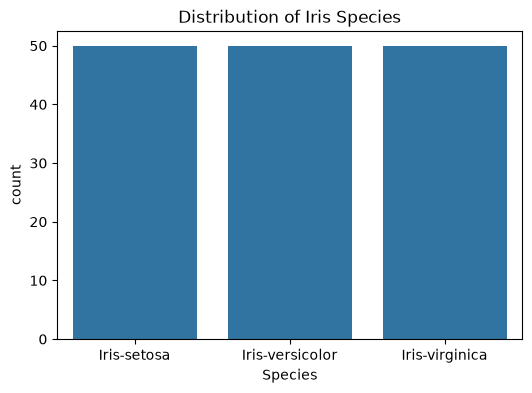

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Species")
plt.title("Distribution of Iris Species")
plt.show()

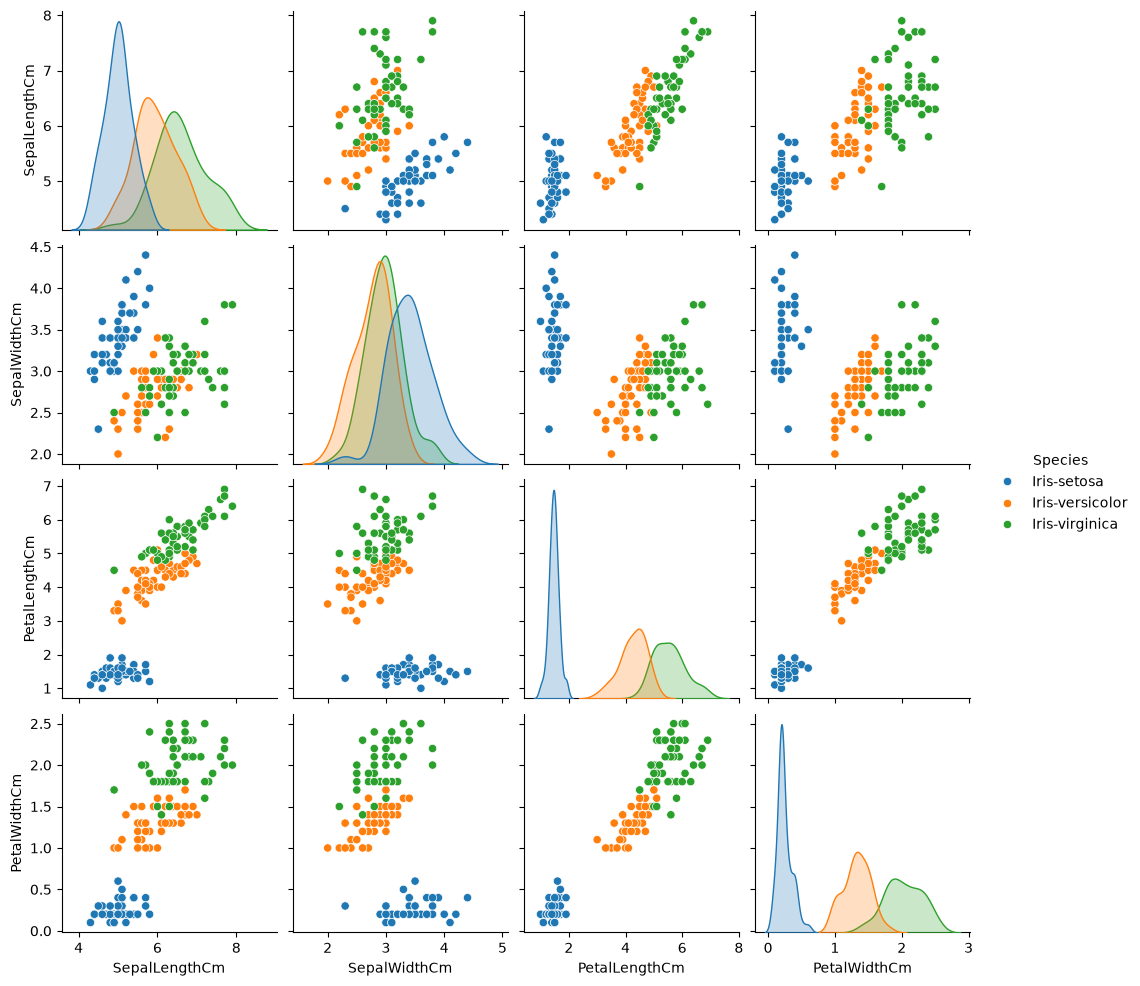

In [10]:
sns.pairplot(df, hue="Species")

Step 5 : prepare the data


In [11]:
X = df.drop(columns=["Species"])
Y = df["Species"]

In [12]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(Y)

In [13]:
X_train , X_test , y_train , y_test = train_test_split(X , y_encoded , test_size = 0.2 , random_state = 42 , stratify=y_encoded)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 6 : train model

In [15]:
print("="*60)
print("How KNN Works")
print("="*60)

print("""
KNN classifies a flower by looking at the K closest flowers
in the training data.

The new flower is assigned to the class that appears
most frequently among its nearest neighbors.
""")

How KNN Works

KNN classifies a flower by looking at the K closest flowers
in the training data.

The new flower is assigned to the class that appears
most frequently among its nearest neighbors.



In [16]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Step 7 : evaluation

In [17]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=encoder.classes_, yticklabels=encoder.classes_
)
plt.xlabel("Predicted species")
plt.ylabel("Actual species")
plt.title("Confusion Matrix — where did the model get confused?")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.close()

Step 8 : picking the best value of K

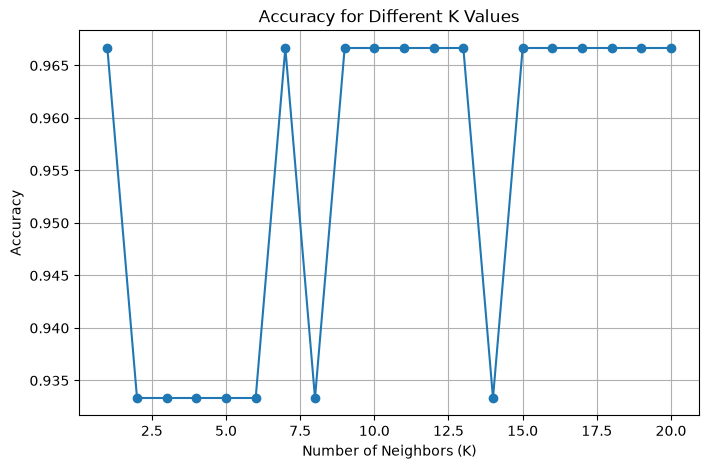

Best K = 1


In [19]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    accuracy = knn.score(X_test_scaled, y_test)
    accuracies.append(accuracy)

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.title("Accuracy for Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best K = {best_k}")

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), accuracies, marker="o", color="teal")
plt.axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"Best K = {best_k}")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy on test set")
plt.title("How accuracy changes as K changes")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.savefig("k_accuracy_plot.png", dpi=120)
plt.close()

Step 9 : try it on a new flower

In [21]:
newflower = pd.DataFrame({
    "SepalLengthCm": [5.9],
    "SepalWidthCm": [3.0],
    "PetalLengthCm": [4.2],
    "PetalWidthCm": [1.5],
})

In [22]:
new_flower_scaled = scaler.transform(newflower)
prediction = model.predict(new_flower_scaled)
predicted_species = encoder.inverse_transform(prediction)[0]

In [23]:
print("="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"""
Dataset Size      : {len(df)} flowers
Training Samples  : {len(X_train)}
Testing Samples   : {len(X_test)}
Algorithm         : K-Nearest Neighbors
Best K            : {best_k}
Accuracy          : {accuracy:.2%}

The model successfully classifies Iris flowers
based on four flower measurements.
""")

PROJECT SUMMARY

Dataset Size      : 150 flowers
Training Samples  : 120
Testing Samples   : 30
Algorithm         : K-Nearest Neighbors
Best K            : 1
Accuracy          : 96.67%

The model successfully classifies Iris flowers
based on four flower measurements.

